In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Load Panel Data for Diffs for Validation

In [2]:
all_beta_df_results_diff = dd.read_csv("Fixed_Windows_Validation_Diff.csv", assume_missing=True).compute()
all_beta_df_results_diff["date"] = pd.to_datetime(all_beta_df_results_diff["date"])
all_beta_df_results_diff = all_beta_df_results_diff.sort_values(by=["fips", "date"])
all_beta_df_results_diff

,fips,days_from_start,date,diff_wsize=2_shift=1,diff_wsize=2_shift=2,diff_wsize=2_shift=3,diff_wsize=2_shift=4,diff_wsize=2_shift=5,diff_wsize=2_shift=6,diff_wsize=2_shift=7,diff_wsize=3_shift=1,diff_wsize=3_shift=2,diff_wsize=3_shift=3,diff_wsize=3_shift=4,diff_wsize=3_shift=5,diff_wsize=3_shift=6,diff_wsize=3_shift=7,diff_wsize=4_shift=1,diff_wsize=4_shift=2,diff_wsize=4_shift=3,diff_wsize=4_shift=4,diff_wsize=4_shift=5,diff_wsize=4_shift=6,diff_wsize=4_shift=7,diff_wsize=5_shift=1,diff_wsize=5_shift=2,diff_wsize=5_shift=3,diff_wsize=5_shift=4,diff_wsize=5_shift=5,diff_wsize=5_shift=6,diff_wsize=5_shift=7,diff_wsize=6_shift=1,diff_wsize=6_shift=2,diff_wsize=6_shift=3,diff_wsize=6_shift=4,diff_wsize=6_shift=5,diff_wsize=6_shift=6,diff_wsize=6_shift=7,diff_wsize=7_shift=1,diff_wsize=7_shift=2,diff_wsize=7_shift=3,diff_wsize=7_shift=4,diff_wsize=7_shift=5,diff_wsize=7_shift=6,diff_wsize=7_shift=7,diff_wsize=8_shift=1,diff_wsize=8_shift=2,diff_wsize=8_shift=3,diff_wsize=8_shift=4,diff_wsize=8_shift=5,diff_wsize=8_shift=6,diff_wsize=8_shift=7,diff_wsize=9_shift=1,diff_wsize=9_shift=2,diff_wsize=9_shift=3,diff_wsize=9_shift=4,diff_wsize=9_shift=5,diff_wsize=9_shift=6,diff_wsize=9_shift=7,diff_wsize=10_shift=1,diff_wsize=10_shift=2,diff_wsize=10_shift=3,diff_wsize=10_shift=4,diff_wsize=10_shift=5,diff_wsize=10_shift=6,diff_wsize=10_shift=7,diff_wsize=11_shift=1,diff_wsize=11_shift=2,diff_wsize=11_shift=3,diff_wsize=11_shift=4,diff_wsize=11_shift=5,diff_wsize=11_shift=6,diff_wsize=11_shift=7,diff_wsize=12_shift=1,diff_wsize=12_shift=2,diff_wsize=12_shift=3,diff_wsize=12_shift=4,diff_wsize=12_shift=5,diff_wsize=12_shift=6,diff_wsize=12_shift=7,diff_wsize=13_shift=1,diff_wsize=13_shift=2,diff_wsize=13_shift=3,diff_wsize=13_shift=4,diff_wsize=13_shift=5,diff_wsize=13_shift=6,diff_wsize=13_shift=7,diff_wsize=14_shift=1,diff_wsize=14_shift=2,diff_wsize=14_shift=3,diff_wsize=14_shift=4,diff_wsize=14_shift=5,diff_wsize=14_shift=6,diff_wsize=14_shift=7
0,1001.0,69.0,2020-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001.0,70.0,2020-03-31,0.014682,0.073987,0.106877,0.148142,0.196434,0.262726,0.332681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001.0,71.0,2020-04-01,0.044623,0.062832,0.089415,0.123026,0.174637,0.229910,0.321336,0.051964,0.077513,0.111437,0.152389,0.211341,0.273954,0.372722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001.0,72.0,2020-04-02,-0.026415,-0.044455,-0.055468,-0.048480,-0.037831,0.008972,0.003182,-0.004103,0.000168,0.011467,0.040767,0.073728,0.142843,0.159363,0.009226,0.026827,0.051455,0.094083,0.140374,0.222817,0.252667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.0,73.0,2020-04-03,0.008375,0.023777,0.057180,0.094245,0.167463,0.188087,0.233440,-0.004832,-0.002638,0.017557,0.041415,0.101425,0.108842,0.140987,0.003272,0.013570,0.041869,0.073831,0.141945,0.157466,0.197715,0.012491,0.032009,0.069528,0.110709,0.1

### Load the Clusters

In [3]:
if os.path.exists("kmeans_clusters_by_fips.csv"):
    print("kmeans_clusters_by_fips.csv exists! Loading...")
    kmeans_clusters_by_fips = pd.read_csv("kmeans_clusters_by_fips.csv")
else:
    print("kmeans_clusters_by_fips.csv does not exist! Generating...")
    hhs_X_w_clusters = pd.read_csv("hhs_X_w_clusters.csv")
    #hhs_X_w_clusters = hhs_X_w_clusters.filter(regex=r'^(fips|kmeans_k=\d+_labels)$')
    hhs_X_w_clusters["fips"] = hhs_X_w_clusters["fips"].astype(np.int64)
    hhs_X_w_clusters["kmeans_k=1_labels"] = 0
    hhs_X_w_clusters["kmeans_k=3136_labels"] = list(range(3136))
    # Get the kmeans_k={} part from column names
    column_names = hhs_X_w_clusters.columns[hhs_X_w_clusters.columns.str.contains(r'kmeans_k=\d+_labels')]
    # Sort the column names based on the numeric part
    sorted_column_names = sorted(column_names, key=lambda x: int(x.split('=')[1].split('_')[0]))
    kmeans_clusters_by_fips = hhs_X_w_clusters[['fips'] + sorted_column_names]
    kmeans_clusters_by_fips.to_csv("kmeans_clusters_by_fips.csv", index=False)
kmeans_clusters_by_fips

kmeans_clusters_by_fips.csv exists! Loading...


,fips,kmeans_k=1_labels,kmeans_k=2_labels,kmeans_k=3_labels,kmeans_k=4_labels,kmeans_k=5_labels,kmeans_k=6_labels,kmeans_k=7_labels,kmeans_k=8_labels,kmeans_k=9_labels,kmeans_k=10_labels,kmeans_k=11_labels,kmeans_k=12_labels,kmeans_k=13_labels,kmeans_k=14_labels,kmeans_k=15_labels,kmeans_k=16_labels,kmeans_k=17_labels,kmeans_k=18_labels,kmeans_k=19_labels,kmeans_k=20_labels,kmeans_k=100_labels,kmeans_k=200_labels,kmeans_k=300_labels,kmeans_k=400_labels,kmeans_k=500_labels,kmeans_k=600_labels,kmeans_k=700_labels,kmeans_k=800_labels,kmeans_k=900_labels,kmeans_k=1000_labels,kmeans_k=1100_labels,kmeans_k=1200_labels,kmeans_k=1300_labels,kmeans_k=1400_labels,kmeans_k=1500_labels,kmeans_k=1600_labels,kmeans_k=1700_labels,kmeans_k=1800_labels,kmeans_k=1900_labels,kmeans_k=2000_labels,kmeans_k=2100_labels,kmeans_k=2200_labels,kmeans_k=2300_labels,kmeans_k=2400_labels,kmeans_k=2500_labels,kmeans_k=2600_labels,kmeans_k=2700_labels,kmeans_k=2800_labels,kmeans_k=2900_labels,kmeans_k=3000_labels,kmeans_k=3100_labels,kmeans_k=3136_labels
0,1001,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,22,152,51,306,28,28,28,28,28,28,704,1197,1197,1197,1197,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1121,1121,0
1,1003,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,43,169,24,24,419,419,419,419,419,419,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,372,488,488,1
2,1005,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,8,141,141,344,65,482,65,65,65,979,803,803,803,803,803,1587,1587,1763,1763,1763,1763,1763,1763,1763,1763,1763,1763,1763,1763,1063,1063,2
3,1007,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,8,9,9,344,65,65,65,65,65,65,226,1104,1104,1104,1104,1104,1104,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1362,1362,3
4,1009,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,46,9,267,339,9,9,657,649,649,649,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,312,1575,1575,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3131,56039,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,38,111,111,393,279,279,279,279,279,279,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,482,434,434,3131
3132,56041,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,10,166,166,304,234,234,234,234,234,234,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,275,275,3132
3133,56043,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,10,166,166,304,234,234,234,473,473,473,5,5,5,5,5,5,1675,1675,1675,1675,1675,1675,1675,1675,1675,1675,1675,2748,2748,2756,2756,3133
3134,56045,0,0,0,0,4,4,4,7,7,7,7,7,7,7,7,7,7,7,7,7,10,166,166,304,473,473,473,473,473,473,754,754,754,754,754,754,754,754,754,754,2043,2043,2043,2043,2043,2043,2043,2043,2043,949,949,3134


### Generate masks given a `K`

In [4]:
def generate_mask(df, K, k):
    """
    Return a sorted list of fips conforming to a mask cluster
    """
    assert isinstance(K, int) and 1 <= K <= 3136, "K must be an integer $\in$ [1,3136]"
    assert isinstance(k, int) and 0 <= k < K, "k must be an integer $\in$ [0,k)"
    fips_list = df[df["kmeans_k={}_labels".format(K)] == k]["fips"].values
    
    return fips_list

In [5]:
def tcv_subroutine(df, fips_list, window_sizes=list(range(2,15)), shift_list=list(range(1,8))):
    """
    Obtain the best window sizes by MAE and RMSE per date given a cluster mask (list of fips)
    """    
    df = df[df["fips"].isin(fips_list)]
    indexing_columns = ["days_from_start","date"]
    daily_metrics_df = df[indexing_columns].drop_duplicates()
    daily_metrics_df = daily_metrics_df.sort_values(by="days_from_start")
    daily_metrics_df = daily_metrics_df.reset_index(drop=True)

    for window_size in window_sizes:
        rmse = df.groupby("date").apply(lambda x : np.sqrt(np.nanmean(np.square(x[["diff_wsize={}_shift={}".format(window_size, s) for s in shift_list]]))))
        mae = df.groupby("date").apply(lambda x : np.nanmean(np.abs(x[["diff_wsize={}_shift={}".format(window_size, s) for s in shift_list]])))

        rmse = pd.DataFrame(rmse).reset_index().rename(columns={0:"rmse_wsize={}".format(window_size)})
        mae = pd.DataFrame(mae).reset_index().rename(columns={0:"mae_wsize={}".format(window_size)})

        daily_metrics_df = pd.merge(daily_metrics_df, mae, on="date", how="left")
        daily_metrics_df = pd.merge(daily_metrics_df, rmse, on="date", how="left")

        #daily_metrics_df["cumsum_mae_wsize={}".format(window_size)] = daily_metrics_df["mae_wsize={}".format(window_size)].cumsum()
        #daily_metrics_df["cumsum_rmse_wsize={}".format(window_size)] = daily_metrics_df["rmse_wsize={}".format(window_size)].cumsum()
    best_wsizes = pd.DataFrame(daily_metrics_df["date"])
    daily_mae_df = daily_metrics_df[["mae_wsize={}".format(window_size) for window_size in window_sizes]]
    best_wsizes["best_mae_window"] = daily_mae_df.idxmin(axis=1).str[-1]
    
    daily_rmse_df = daily_metrics_df[["rmse_wsize={}".format(window_size) for window_size in window_sizes]]
    best_wsizes["best_rmse_window"] = daily_rmse_df.idxmin(axis=1).str[-1]
    
    best_wsizes = best_wsizes[~best_wsizes["best_rmse_window"].isna()]
    best_wsizes = best_wsizes[~best_wsizes["best_mae_window"].isna()]
    
    best_wsizes["best_mae_window"] = best_wsizes["best_mae_window"].astype(np.int64)
    best_wsizes["best_rmse_window"] = best_wsizes["best_rmse_window"].astype(np.int64)
    
    best_wsizes = best_wsizes[best_wsizes["best_mae_window"] >= 2]
    best_wsizes = best_wsizes[best_wsizes["best_rmse_window"] >= 2]    
    
    return best_wsizes


In [6]:
def tcv_worker(all_beta_df_results_diff, kmeans_clusters_by_fips, Kk, window_sizes=list(range(2,15)), shift_list=list(range(1,8))):
    K, k = Kk
    print("tcv_worker on Cluster=({},{})".format(K,k))
    fips_list = generate_mask(kmeans_clusters_by_fips, K, k)
    best_wsizes = tcv_subroutine(all_beta_df_results_diff, fips_list, window_sizes=list(range(2,15)), shift_list=list(range(1,8)))
    best_wsizes["K"] = K
    best_wsizes["k"] = k
    best_wsizes = best_wsizes[["K","k","date","best_mae_window", "best_rmse_window"]]
    return best_wsizes

In [10]:
Kk = (1,0)
K, k = Kk
best_wsizes = tcv_worker(all_beta_df_results_diff, kmeans_clusters_by_fips, Kk, window_sizes=list(range(2,15)), shift_list=list(range(1,8)))

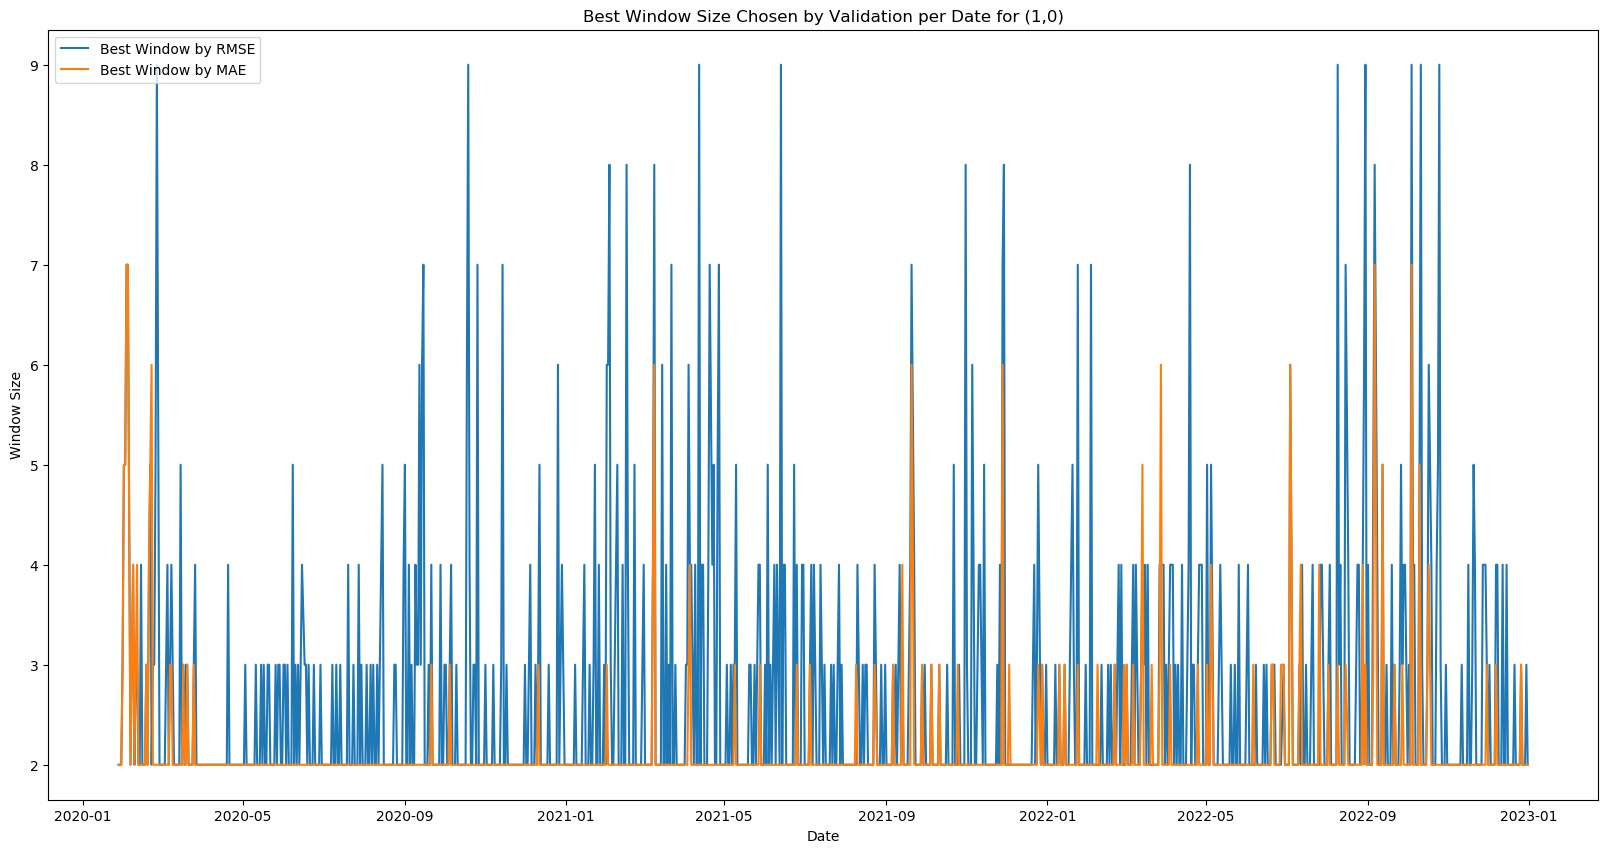

In [11]:
plt.figure(figsize=(20,10))
plt.plot(best_wsizes["date"],best_wsizes["best_rmse_window"],label="Best Window by RMSE")
plt.plot(best_wsizes["date"],best_wsizes["best_mae_window"],label="Best Window by MAE")
plt.xlabel("Date")
plt.ylabel("Window Size")
plt.title("Best Window Size Chosen by Validation per Date for ({},{})".format(K,k))
plt.legend()
plt.show()


In [12]:
best_wsizes

,K,k,date,best_mae_window,best_rmse_window
1,1,0,2020-01-28,2,2
2,1,0,2020-01-29,2,2
3,1,0,2020-01-30,2,2
4,1,0,2020-01-31,3,3
5,1,0,2020-02-01,5,5
...,...,...,...,...,...
1065,1,0,2022-12-27,2,2
1066,1,0,2022-12-28,2,2
1067,1,0,2022-12-29,2,2
1068,1,0,2022-12-30,2,3


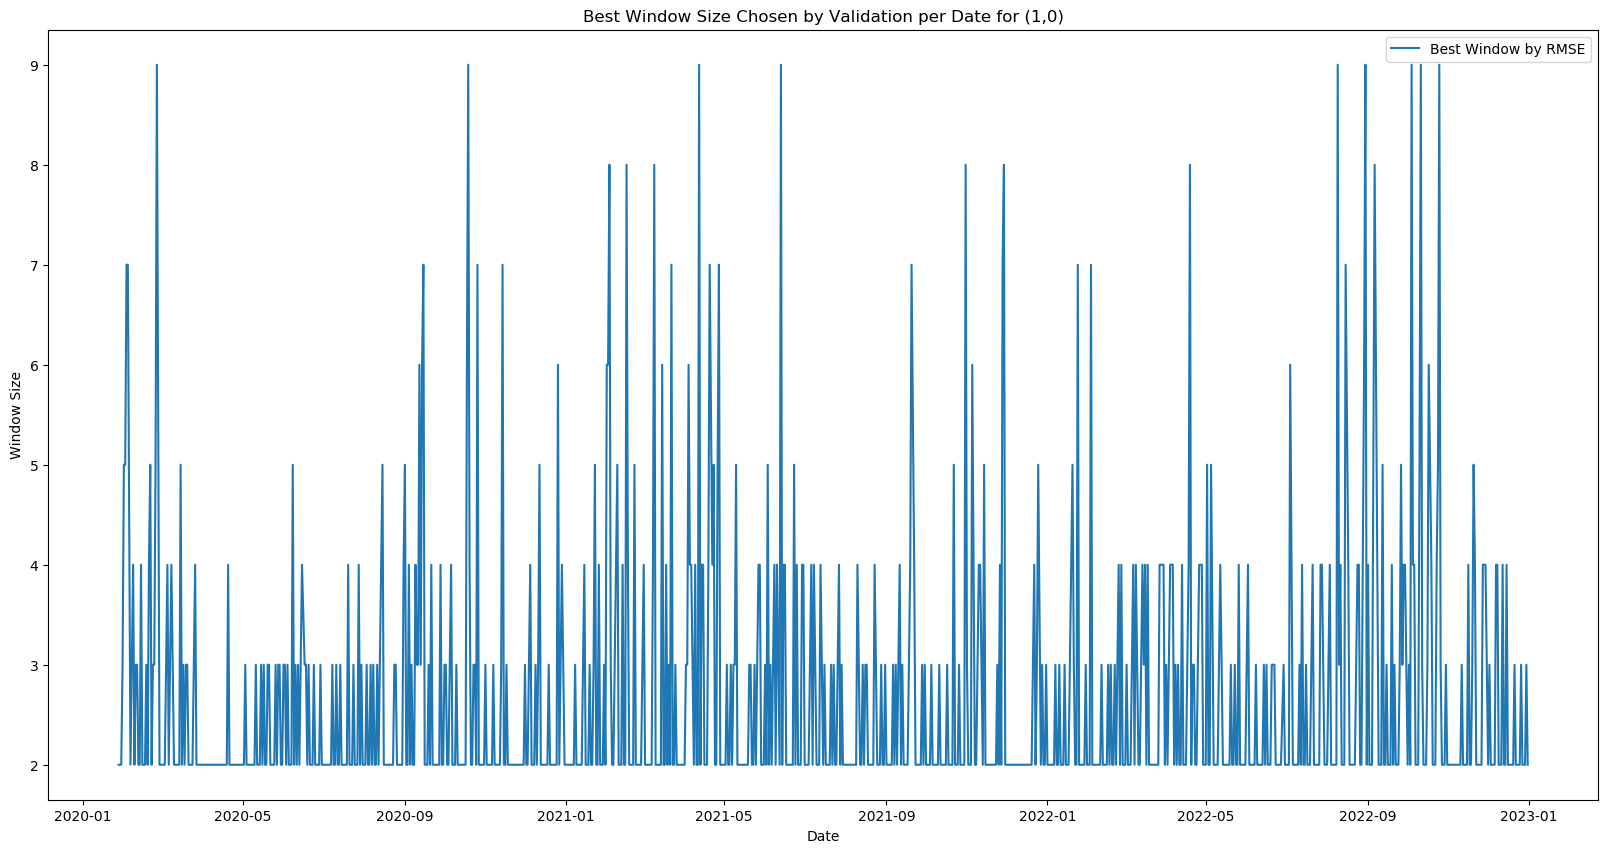

In [14]:
plt.figure(figsize=(20,10))
plt.plot(best_wsizes["date"],best_wsizes["best_rmse_window"],label="Best Window by RMSE")
#plt.plot(best_wsizes["date"],best_wsizes["best_mae_window"],label="Best Window by MAE")
plt.xlabel("Date")
plt.ylabel("Window Size")
plt.title("Best Window Size Chosen by Validation per Date for ({},{})".format(K,k))
plt.legend()
plt.show()


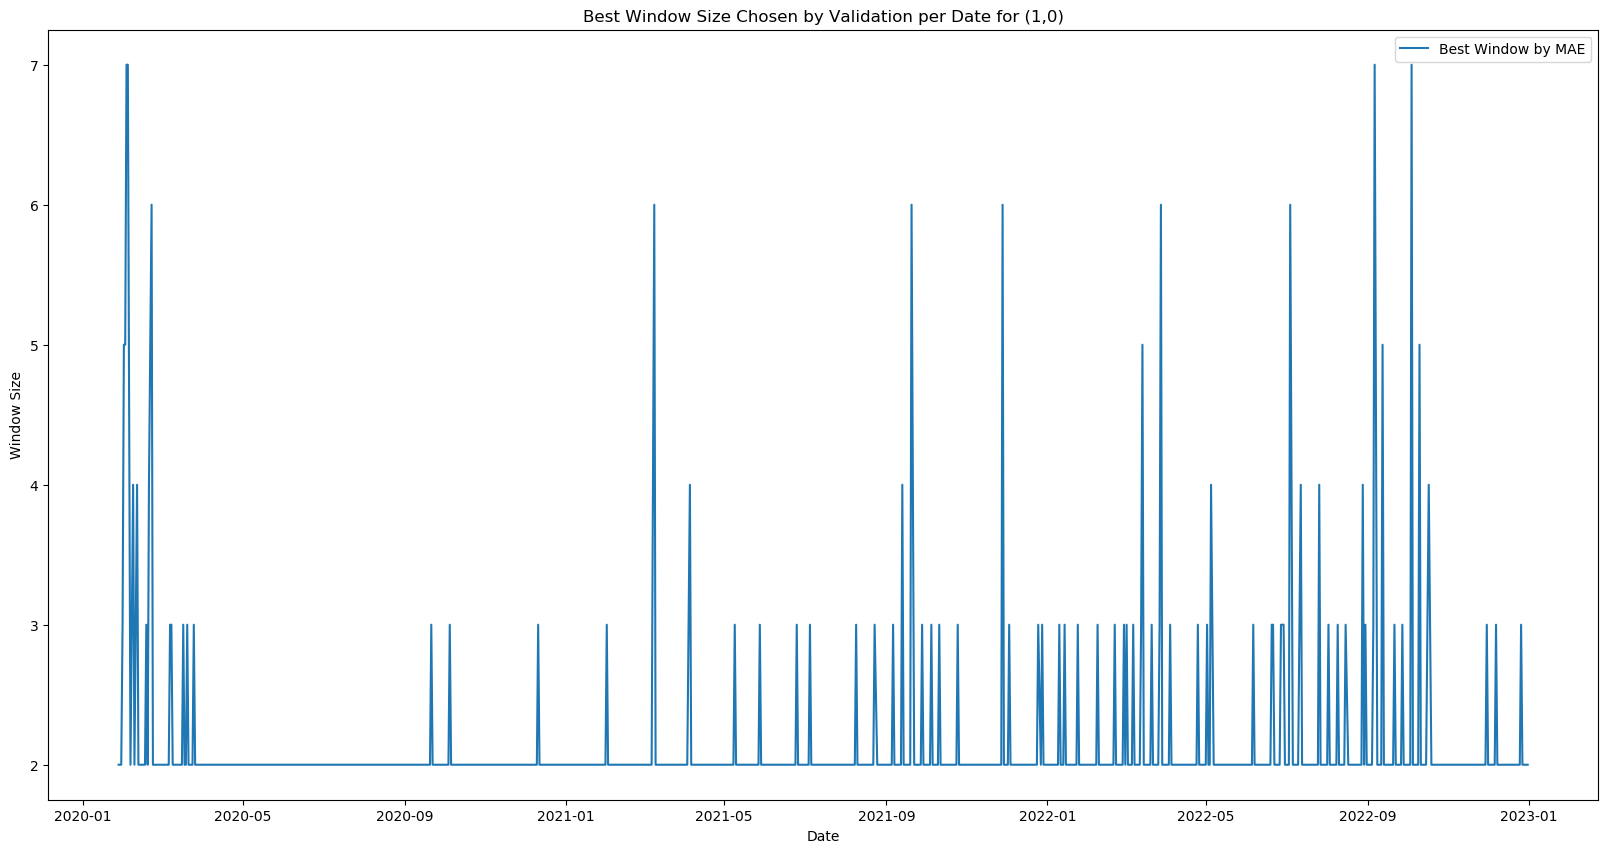

In [15]:
plt.figure(figsize=(20,10))
#plt.plot(best_wsizes["date"],best_wsizes["best_rmse_window"],label="Best Window by RMSE")
plt.plot(best_wsizes["date"],best_wsizes["best_mae_window"],label="Best Window by MAE")
plt.xlabel("Date")
plt.ylabel("Window Size")
plt.title("Best Window Size Chosen by Validation per Date for ({},{})".format(K,k))
plt.legend()
plt.show()

In [17]:
best_wsizes["best_mae_window"].value_counts()

2    963
3     59
4     11
5      6
6      6
7      4
Name: best_mae_window, dtype: int64

In [18]:
best_wsizes["best_rmse_window"].value_counts()

2    688
3    183
4    108
5     29
7     13
6     12
9      9
8      7
Name: best_rmse_window, dtype: int64